# 04 — Visualizações Finais & Dashboard
**Responsável**: P2 (Presencial)

**Objetivo**: Gráficos finais para apresentação, combinando resultados do modelo supervisionado e clustering.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar resultados
df_feat = pd.read_parquet('../data/processed/artist_country_features.parquet')
df_scores = pd.read_csv('../data/processed/model_results.csv')
df_clusters = pd.read_csv('../data/processed/cluster_labels.csv')

# Merge
df = df_feat.merge(df_scores[['artist_uri','country','recommend_score','recommend_label']],
    on=['artist_uri','country'], how='left')
df = df.merge(df_clusters[['artist_uri','country','cluster','profile']],
    on=['artist_uri','country'], how='left')
print(f'Shape: {df.shape}')

Shape: (13120, 24)


## 1. Ranking Final por País — Top 20 Recomendações

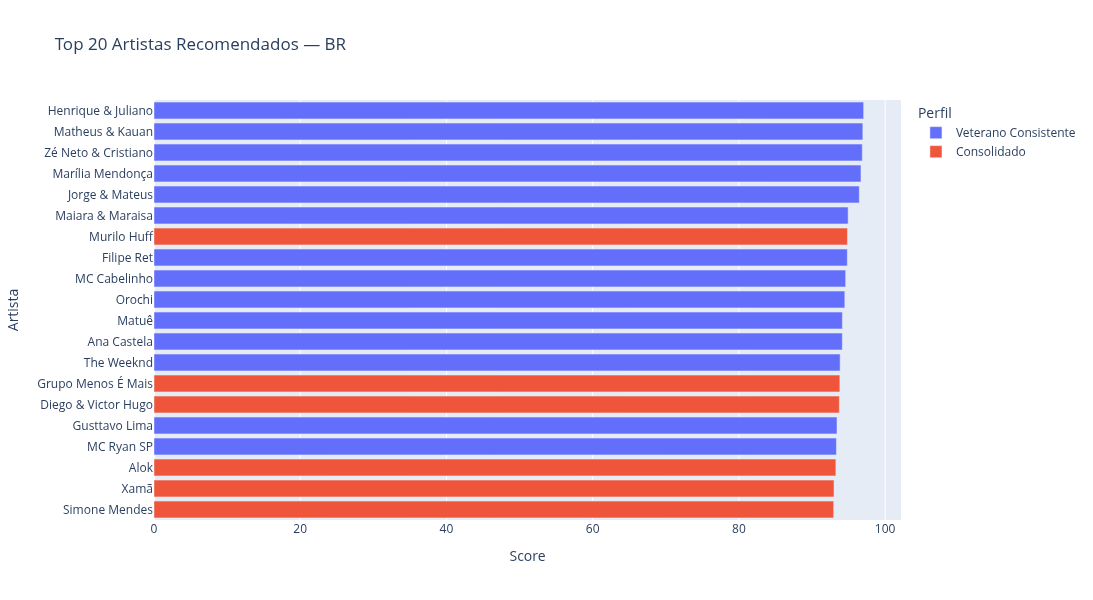

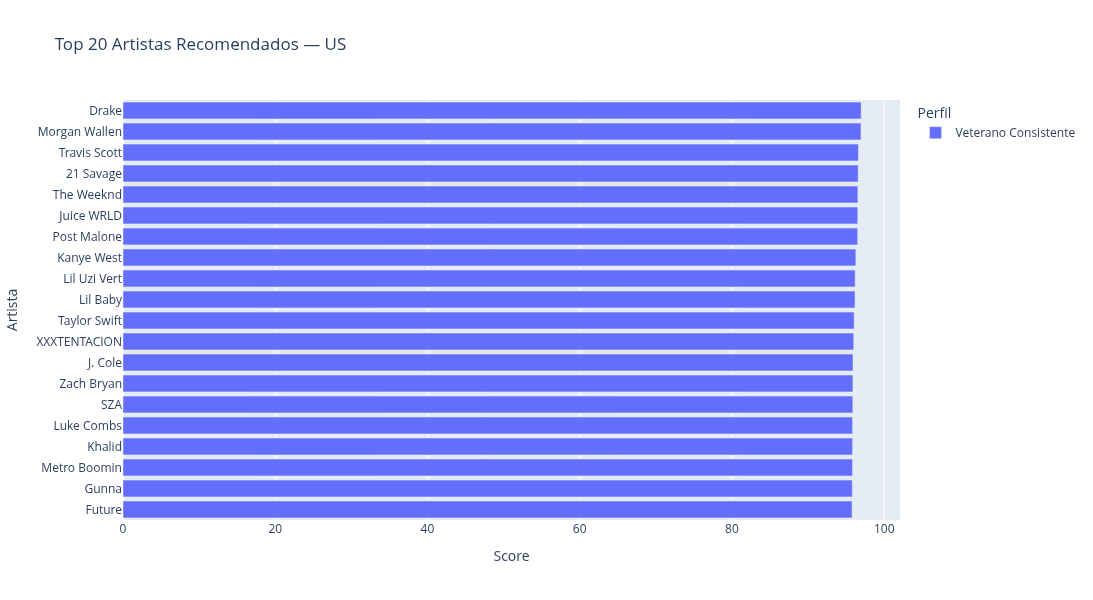

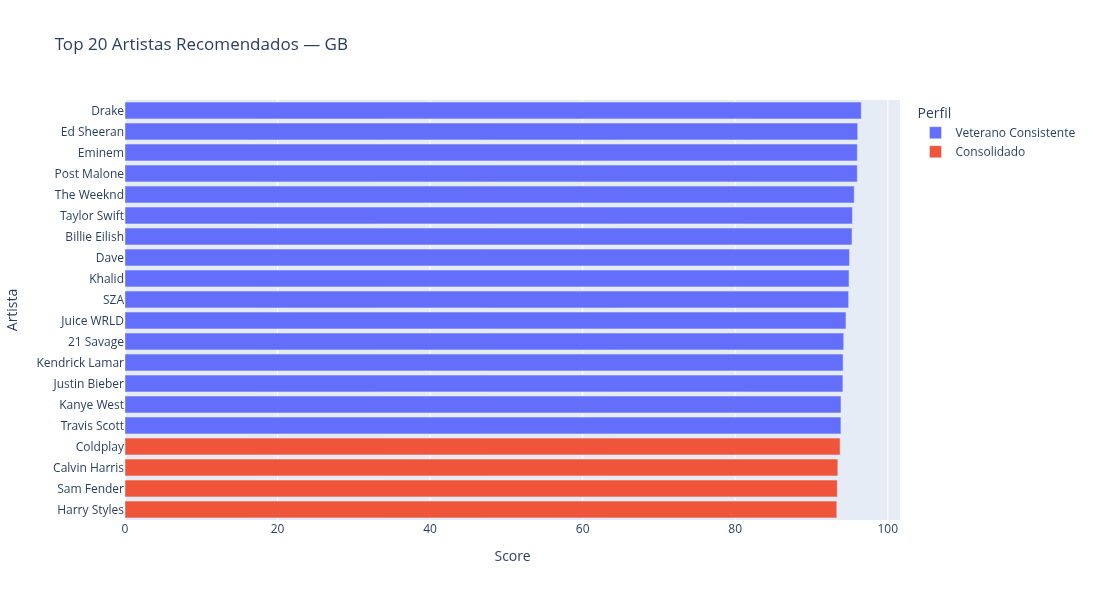

In [2]:
for country in ['br', 'us', 'gb']:
    top = df[df['country']==country].nlargest(20, 'recommend_score')
    fig = px.bar(top, x='recommend_score', y='artist_name',
        orientation='h', color='profile',
        title=f'Top 20 Artistas Recomendados — {country.upper()}',
        labels={'recommend_score':'Score','artist_name':'Artista','profile':'Perfil'})
    fig.update_layout(yaxis={'categoryorder':'total ascending'}, height=600)
    fig.show()

## 2. Scatter: Score vs Streams, colorido por Perfil

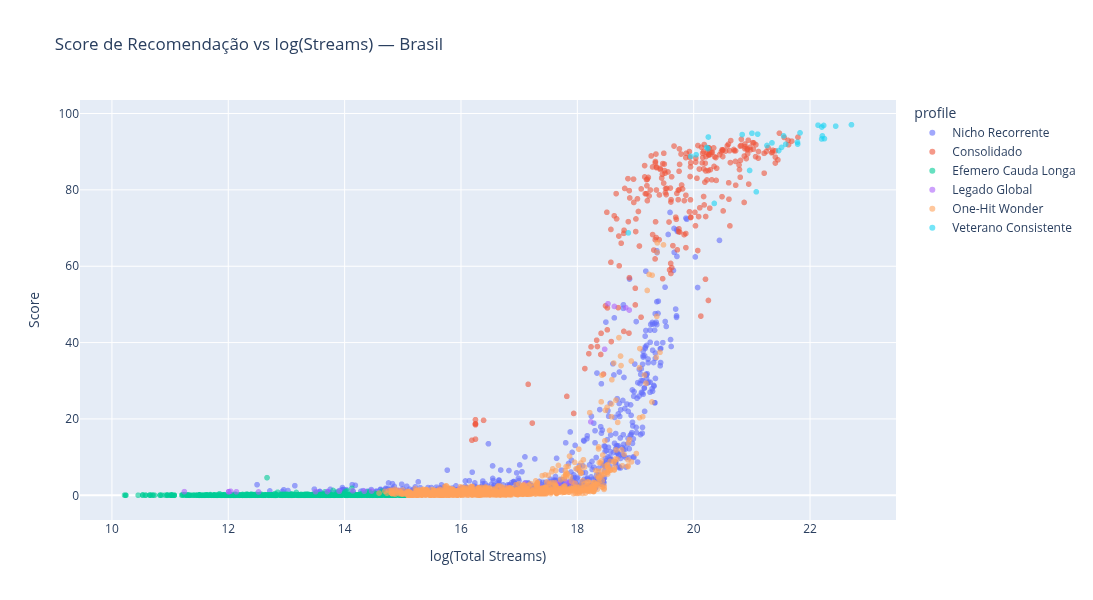

In [3]:
df_br = df[df['country']=='br'].dropna(subset=['recommend_score','profile']).copy()
df_br['log_streams'] = np.log1p(df_br['total_streams'])

fig = px.scatter(df_br, x='log_streams', y='recommend_score',
    color='profile', hover_data=['artist_name','total_tracks','avg_rank'],
    title='Score de Recomendação vs log(Streams) — Brasil',
    labels={'log_streams':'log(Total Streams)','recommend_score':'Score'},
    opacity=0.6)
fig.update_layout(height=600)
fig.show()

## 3. Heatmap: Presença de Artista por País

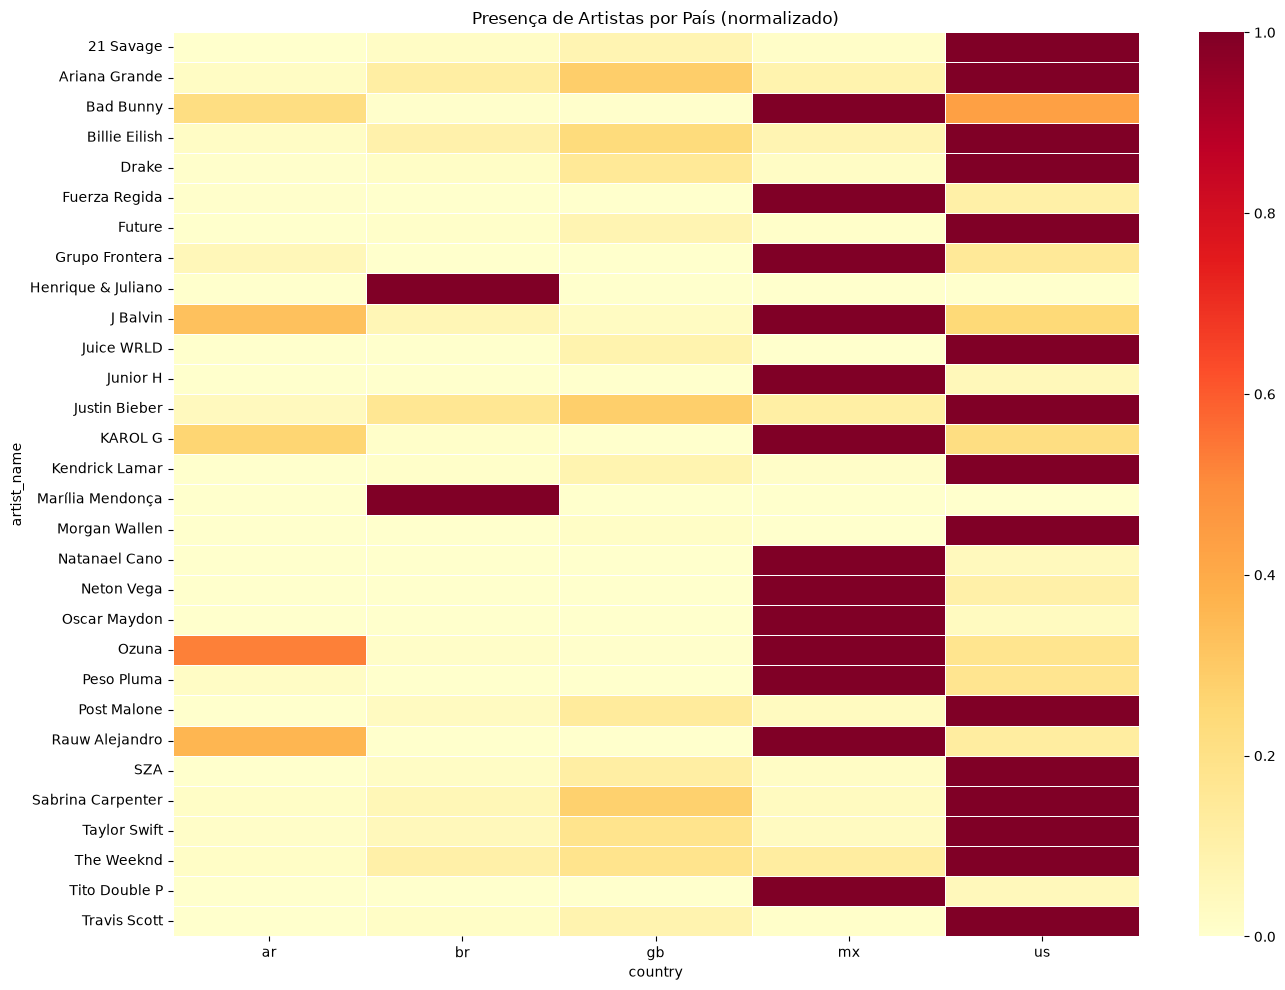

In [4]:
# Top 30 artistas globais
top_global = df.groupby('artist_name')['total_streams'].sum().nlargest(30).index
matrix = df[df['artist_name'].isin(top_global)].pivot_table(
    index='artist_name', columns='country', values='total_streams', aggfunc='sum').fillna(0)
matrix_norm = matrix.div(matrix.max(axis=1), axis=0)  # normalizar por artista

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(matrix_norm, cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Presença de Artistas por País (normalizado)')
plt.tight_layout()
plt.savefig('../docs/heatmap_artist_country.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Distribuição de Perfis por País

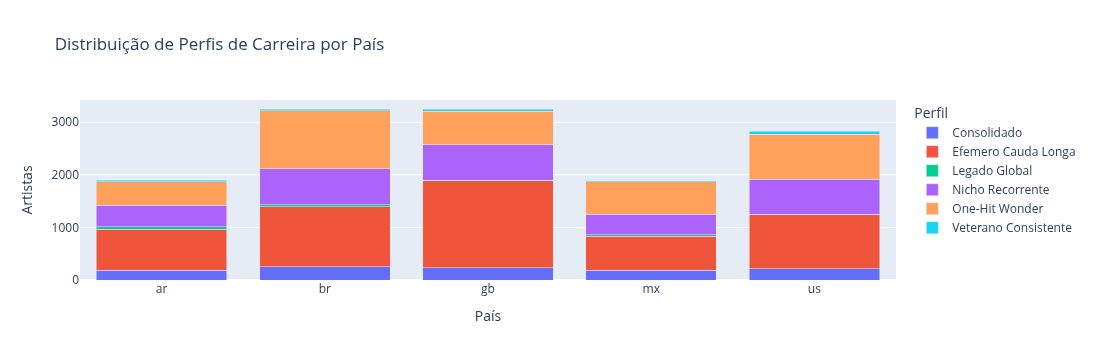

In [5]:
profile_counts = df.groupby(['country','profile']).size().reset_index(name='count')
fig = px.bar(profile_counts, x='country', y='count', color='profile',
    title='Distribuição de Perfis de Carreira por País',
    barmode='stack', labels={'count':'Artistas','country':'País','profile':'Perfil'})
fig.show()

## 5. Resultado Final — Tabela Interativa

In [6]:
# Tabela final para o produtor de eventos
country_input = 'br'  # ALTERAR para o país desejado
n_top = 50

final = df[df['country']==country_input].nlargest(n_top, 'recommend_score')[
    ['artist_name','recommend_score','profile','total_tracks','total_streams',
     'avg_rank','best_rank','stream_concentration','listener_ratio','trend_30d']
].reset_index(drop=True)
final.index += 1
final.columns = ['Artista','Score','Perfil','Tracks','Streams Total',
    'Rank Médio','Melhor Rank','Concentração','Ratio Ouvintes','Trend 30d']
final

,Artista,Score,Perfil,Tracks,Streams Total,Rank Médio,Melhor Rank,Concentração,Ratio Ouvintes,Trend 30d
1,Henrique & Juliano,97.056754,Veterano Consistente,214,7.304741e+09,91.875012,1,0.054540,0.846691,-0.195547
2,Matheus & Kauan,96.943465,Veterano Consistente,142,4.113411e+09,84.419006,1,0.053435,0.893755,0.304108
3,Zé Neto & Cristiano,96.869711,Veterano Consistente,125,4.529850e+09,84.609811,1,0.069003,0.986541,0.290027
4,Marília Mendonça,96.689542,Veterano Consistente,175,5.570857e+09,97.584364,1,0.069523,0.793583,0.781607
5,Jorge & Mateus,96.460212,Veterano Consistente,125,4.389975e+09,88.535220,1,0.049665,0.853598,-0.231575
6,Maiara & Maraisa,94.935674,Veterano Consistente,121,3.016666e+09,82.980423,1,0.077953,0.677197,19.711839
7,Murilo Huff,94.839951,Consolidado,58,2.117237e+09,83.131610,1,0.088959,0.972127,-0.038808
8,Filipe Ret,94.821859,Veterano Consistente,64,1.320019e+09,119.058776,2,0.167959,0.927219,0.348614
9,MC Cabelinho,94.596147,Veterano Consistente,62,1.456881e+09,111.545914,1,0.161487,0.706566,0.558453
10,Orochi,94.478123,Veterano Consistente,72,1.116589e+09,122.711149,6,0.198559,0.835096,0.068036
